# Chess Coach — Exploratory Data Analysis

Walks through the player dataset, the 13-dimensional playstyle feature space, and the K-Means clusters built on it.

All figures are saved to `docs/figures/` so they can be referenced from the README.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Make src/ importable when running the notebook from notebooks/
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from chess_coach.features import FEATURE_COLUMNS

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path.cwd().parent / 'data'
FIG_DIR = Path.cwd().parent / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 1. Dataset overview

In [2]:
games = pl.read_parquet(DATA_DIR / 'games.parquet')
features = pl.read_parquet(DATA_DIR / 'features.parquet')
clustered = pl.read_parquet(DATA_DIR / 'players_clustered.parquet')

print(f'Games:                       {games.height:>7,}')
print(f'Players (raw):               {games["username"].n_unique():>7}')
print(f'Players (after min_games):   {features.height:>7}')
print(f'Rating range:                {features["avg_rating"].min():.0f} – {features["avg_rating"].max():.0f}')
print(f'Avg games per player:        {features["n_games"].mean():.1f}')


Games:                        27,757
Players (raw):                   284
Players (after min_games):       281
Rating range:                784 – 3014
Avg games per player:        98.7


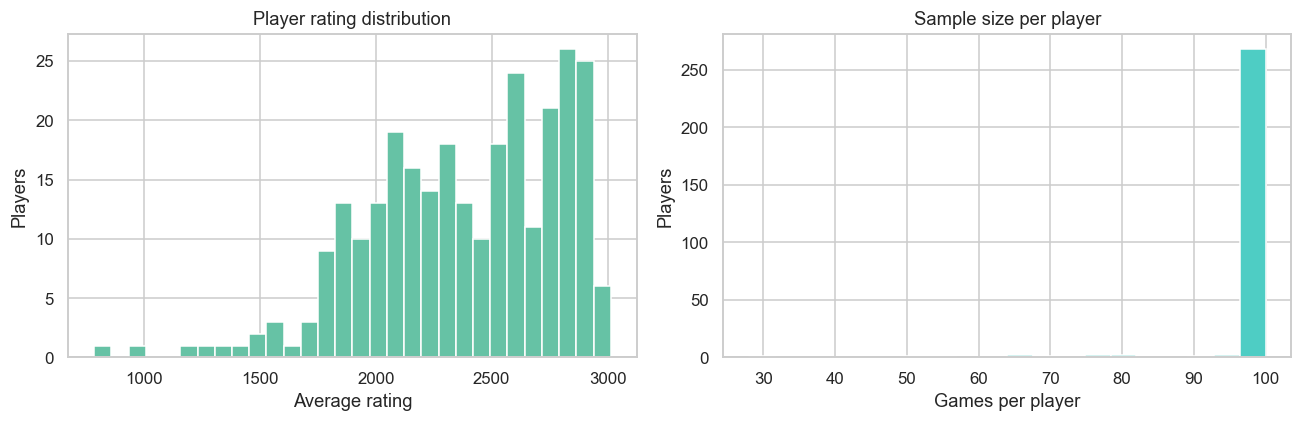

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(features['avg_rating'], bins=30, edgecolor='white')
ax.set(xlabel='Average rating', ylabel='Players', title='Player rating distribution')

ax = axes[1]
ax.hist(features['n_games'], bins=20, edgecolor='white', color='#4ECDC4')
ax.set(xlabel='Games per player', ylabel='Players', title='Sample size per player')

fig.tight_layout()
fig.savefig(FIG_DIR / '01_dataset_overview.png', bbox_inches='tight')
plt.show()


## 2. Feature distributions

Each player is represented by 13 features. Two design choices:

- **Skill adjustment** via Elo expected score — `score_residual` is actual score minus what Elo predicts given opponent ratings. A `+0.05` means the player over-performs their rating by 5 score points per game on average. Orthogonal to raw strength.
- **Opening family proportions** built from ECO code prefixes (`B`/`C` = 1.e4 systems, `D`/`E` = 1.d4). No PGN parsing needed.

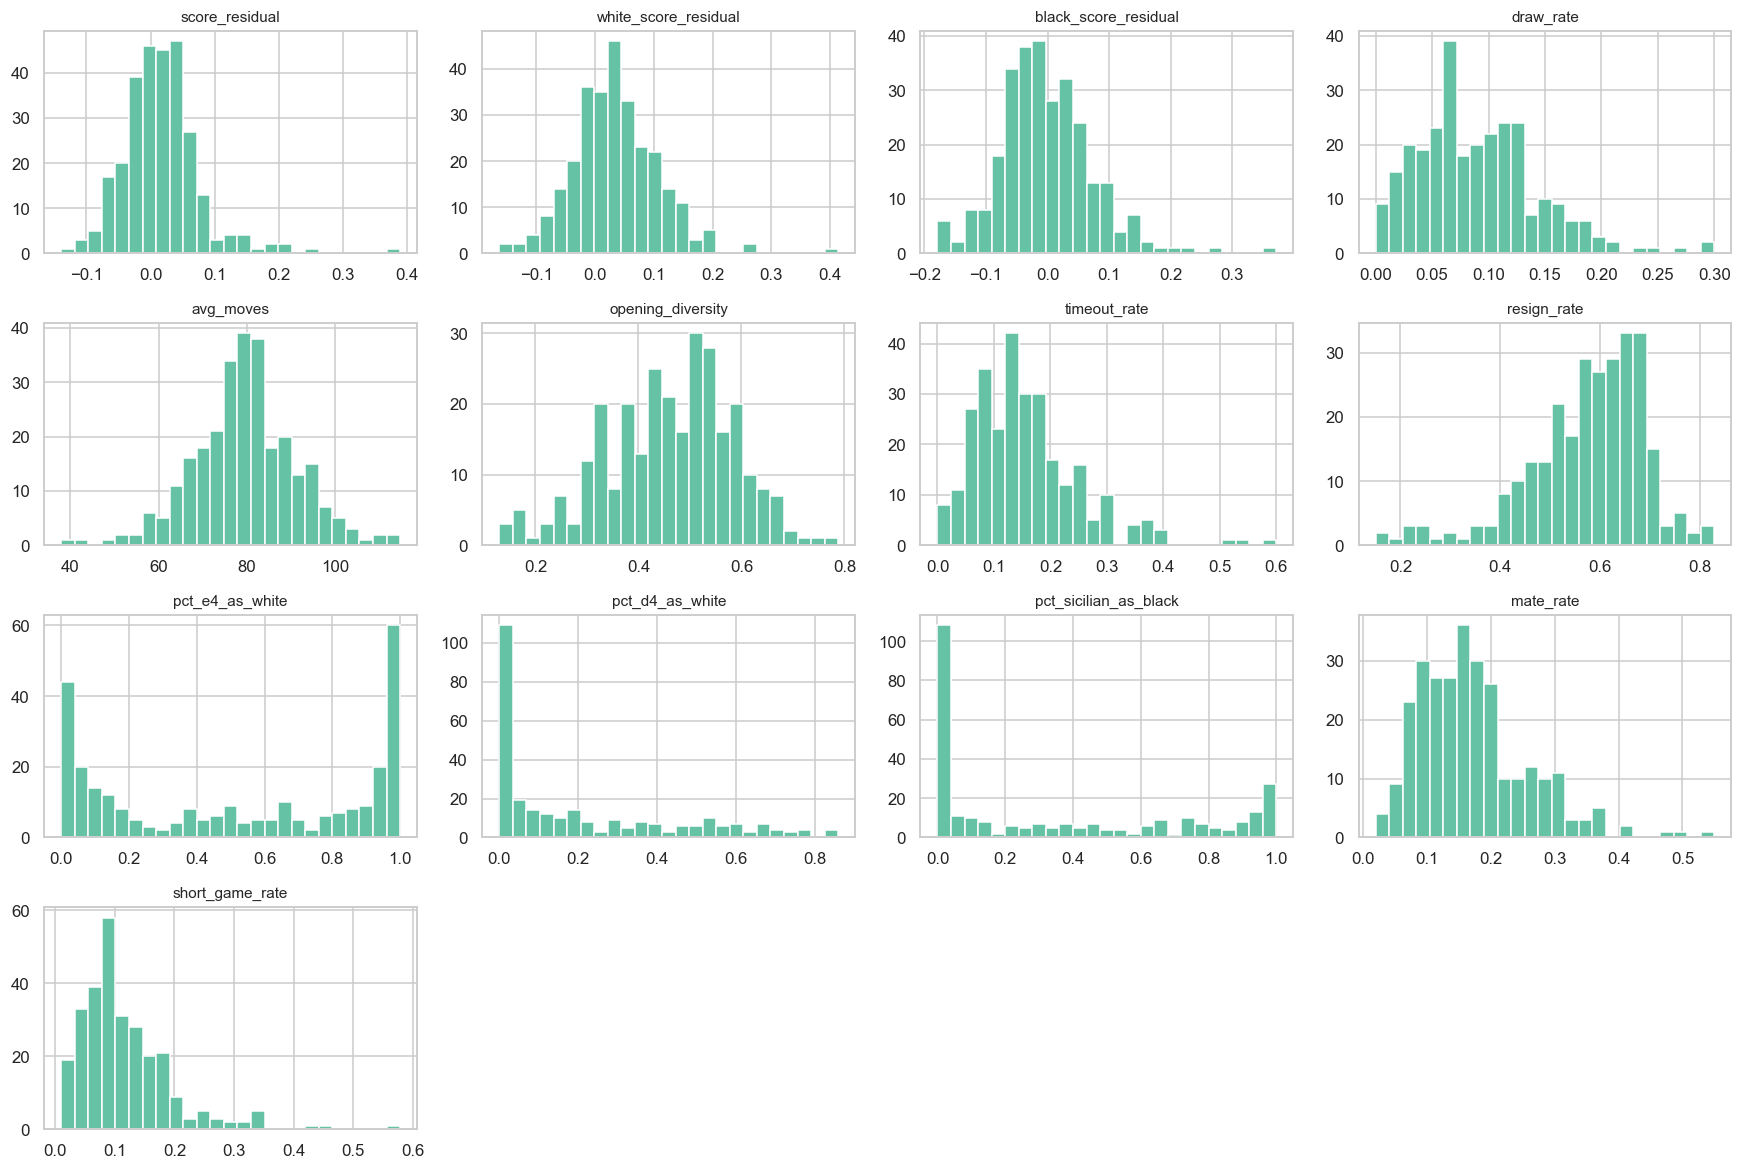

In [4]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURE_COLUMNS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.7*n_rows))

for ax, col in zip(axes.flat, FEATURE_COLUMNS):
    ax.hist(features[col], bins=25, edgecolor='white')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(FEATURE_COLUMNS):]:
    ax.set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / '02_feature_distributions.png', bbox_inches='tight')
plt.show()


## 3. Feature correlations

Heavily correlated features add redundancy without information. Anything > 0.8 in absolute value is worth flagging.

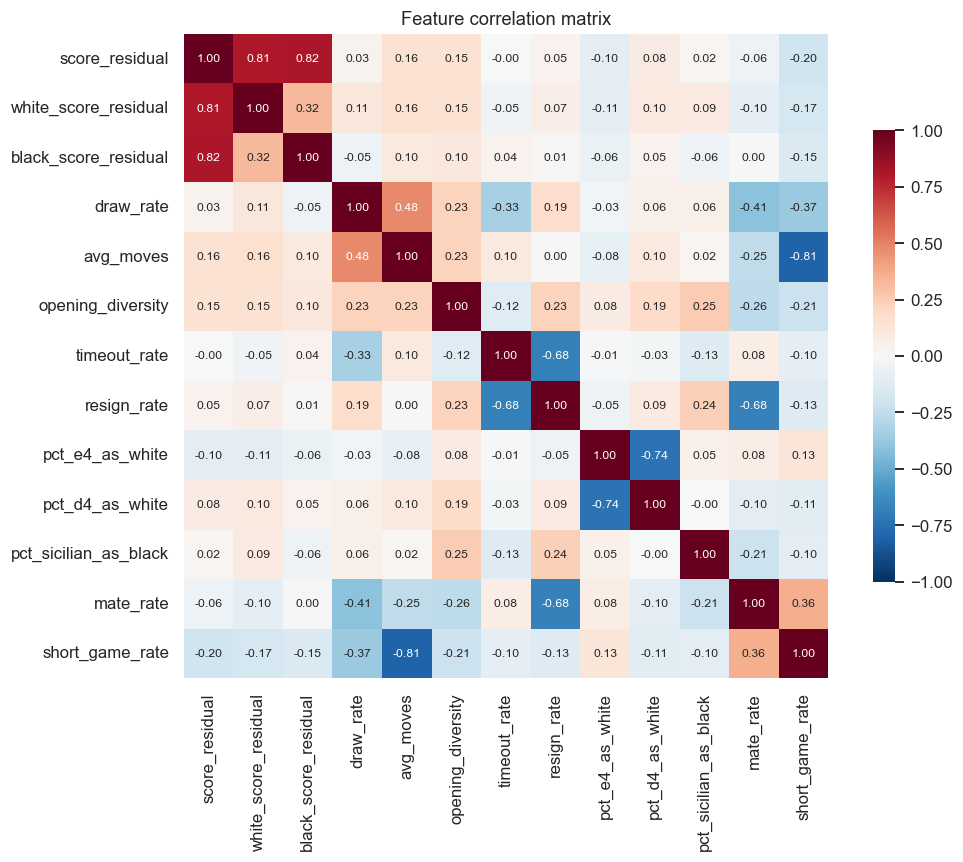

In [5]:
features_pd = features.select(FEATURE_COLUMNS).to_pandas()
corr = features_pd.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'fontsize': 8}, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation matrix')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_correlations.png', bbox_inches='tight')
plt.show()


**Reading the matrix:**

- `score_residual` is highly correlated with `white_score_residual` and `black_score_residual` by construction — they're sub-aggregates of the same quantity. Carrying all three lets the model give different weight to White vs Black performance.
- `pct_e4_as_white` and `pct_d4_as_white` are strongly negative (≈ -1) — a player who plays 1.e4 80% of the time can only play 1.d4 at most 20%. This is the kind of perfect anti-correlation that suggests we could drop one feature, but keeping both makes downstream interpretation cleaner.
- `resign_rate` and `mate_rate` trade off — losing on resignation excludes losing by checkmate.

## 4. PCA projection

13-dimensional feature space projected to 2D for visualisation. Each point is a player, coloured first by K-Means cluster (left), then by rating (right) — to see whether the clusters are tracking style or just rating.

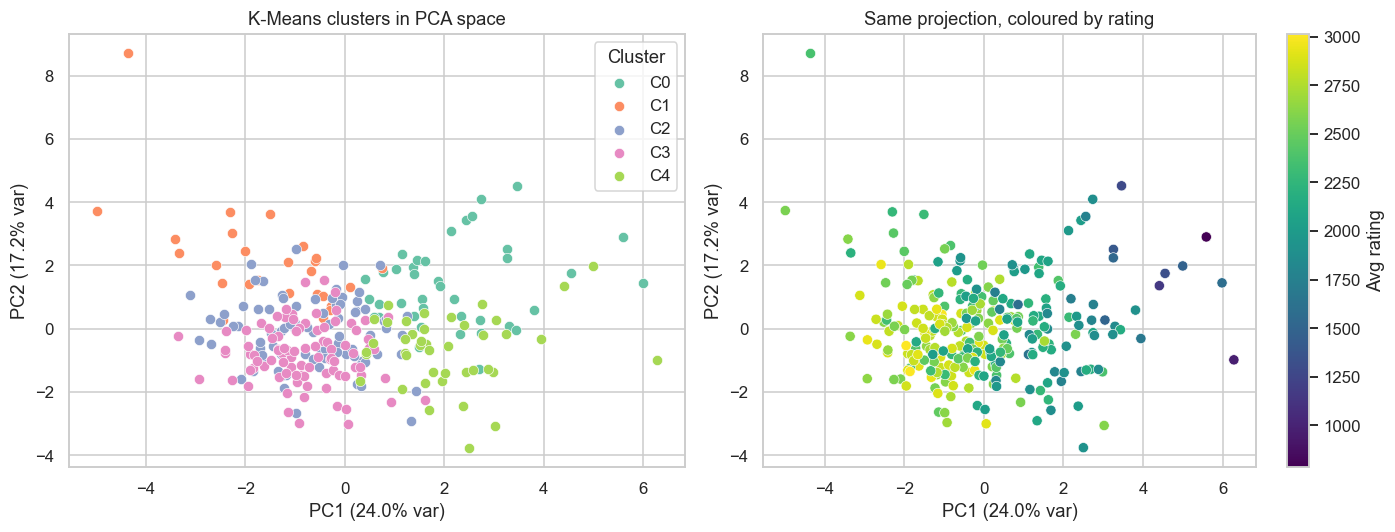

Total variance explained by 2 PCs: 41.2%


In [6]:
X = clustered.select(FEATURE_COLUMNS).to_numpy()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

clusters_arr = clustered['cluster'].to_numpy()
ratings_arr = clustered['avg_rating'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in sorted(set(clusters_arr.tolist())):
    mask = clusters_arr == c
    ax.scatter(pcs[mask, 0], pcs[mask, 1], s=45, label=f'C{c}', edgecolor='white', linewidth=0.4)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
       title='K-Means clusters in PCA space')
ax.legend(title='Cluster', loc='best', frameon=True)

ax = axes[1]
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=ratings_arr, cmap='viridis', s=45, edgecolor='white', linewidth=0.4)
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)',
       title='Same projection, coloured by rating')
fig.colorbar(sc, ax=ax, label='Avg rating')

fig.tight_layout()
fig.savefig(FIG_DIR / '04_pca.png', bbox_inches='tight')
plt.show()

print(f'Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')


**Reading the PCA plots:**

If clusters tracked *only* rating, the left and right plots would look identical. The fact that they differ means clusters capture **style on top of rating** — exactly what the skill-adjustment design was meant to surface.

## 5. Cluster characterisation

Heatmap of cluster-mean values for each feature, z-scored *across clusters* so each row highlights what makes that feature distinctive between clusters.

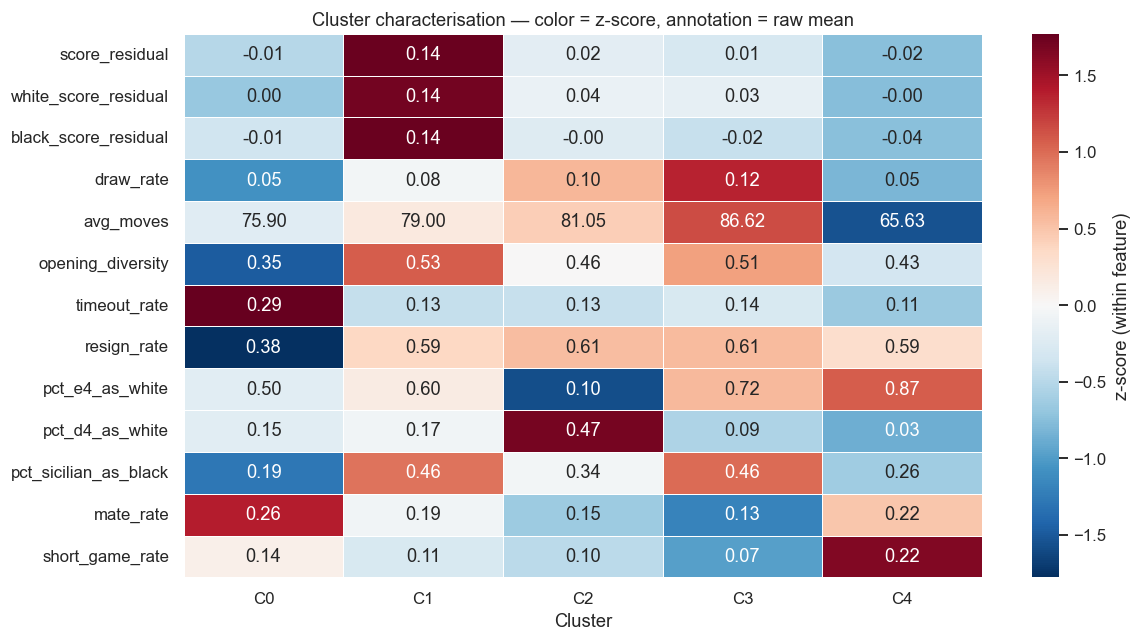

In [7]:
cluster_means = clustered.group_by('cluster').agg([pl.col(c).mean() for c in FEATURE_COLUMNS]).sort('cluster')
cm_df = cluster_means.select(FEATURE_COLUMNS).to_pandas()
cm_df.index = [f'C{i}' for i in cluster_means['cluster'].to_list()]

# Z-score across clusters for each feature (per row, after transpose)
cm_z = (cm_df - cm_df.mean()) / cm_df.std()

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(cm_z.T, annot=cm_df.T, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'z-score (within feature)'}, linewidths=0.4)
ax.set_title('Cluster characterisation — color = z-score, annotation = raw mean')
ax.set_xlabel('Cluster')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_cluster_means.png', bbox_inches='tight')
plt.show()


## 6. Opening-family preference by cluster

The clearest behavioural signal: how each cluster splits between 1.e4 and 1.d4 as White.

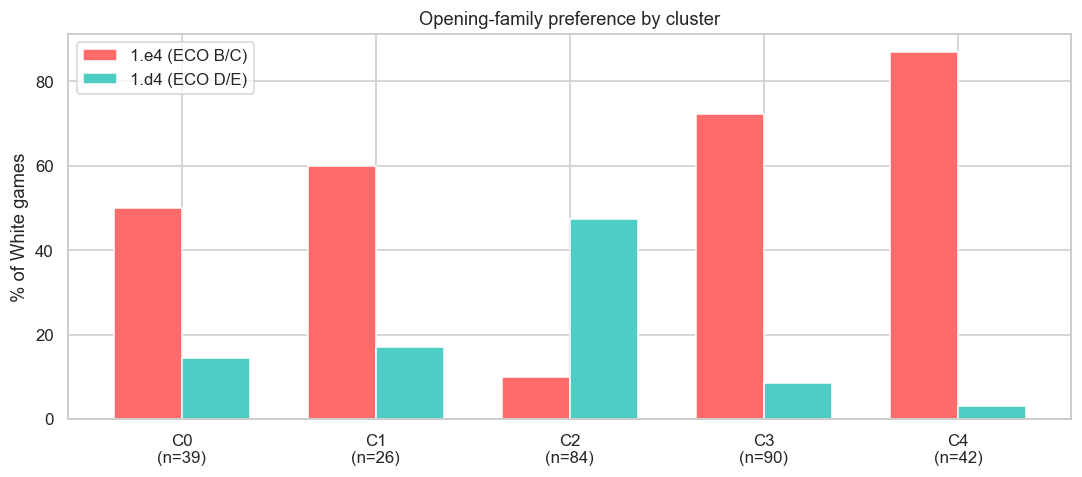

In [8]:
cluster_sizes = clustered.group_by('cluster').len().sort('cluster')
labels = [f'C{i}\n(n={n})' for i, n in zip(cluster_sizes['cluster'], cluster_sizes['len'])]

x = np.arange(len(labels))
width = 0.35
e4 = cm_df['pct_e4_as_white'].values * 100
d4 = cm_df['pct_d4_as_white'].values * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, e4, width, label='1.e4 (ECO B/C)', color='#FF6B6B', edgecolor='white')
ax.bar(x + width/2, d4, width, label='1.d4 (ECO D/E)', color='#4ECDC4', edgecolor='white')
ax.set(xticks=x, xticklabels=labels, ylabel='% of White games',
       title='Opening-family preference by cluster')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '06_openings_by_cluster.png', bbox_inches='tight')
plt.show()


## Cluster identities

Reading the heatmap above and the opening bar chart:

| Cluster | Avg rating | Identity |
| --- | --- | --- |
| **0** | ~2000 | Blitz brawlers — ~29% time-loss, low draws, ~50% 1.e4 |
| **1** | ~2310 | Underrated overperformers — score residual +0.14, ~46% Sicilians as Black |
| **2** | ~2480 | 1.d4 specialists — 47% d4, only 10% e4 |
| **3** | ~2670 | Elite e4 generalists — top ratings, 72% e4, longest games |
| **4** | ~1965 | 1.e4 dogmatists — 87% e4, short decisive games |

Each identity emerges from a *combination* of features. Cluster 4 and Cluster 0 are both ~2000-rated and play 1.e4, but Cluster 0 burns the clock and Cluster 4 has the shortest games. K-Means is picking up these multi-feature signatures.

## Limitations & next steps

- **Silhouette ~0.13**, meaning clusters are not crisply separated. Likely because chess playstyle is a continuum rather than a discrete partition. Could try Gaussian Mixture Models or continuous embeddings.
- **`pct_e4_as_white` ↔ `pct_d4_as_white` correlation near -1** — could drop one feature without information loss; kept for downstream interpretability.
- **No move-level features** — adding centipawn loss, tactical pattern density, or piece activity (all needing Stockfish) is Phase 3.
- **Underrepresented rating bands** — only 22 of 281 players are < 1800. Phase 4 (training on monthly Lichess database dumps) addresses this.